# nb01 — распределение стопов (концентрация хвостового риска)

**Вопросы пользователя:**
1. Бывают дни, когда стратегия ловит **много стопов подряд**. Посмотреть **LABUSDT** за последние
   ~3 недели (данные докачаны до 2026-07-14) — как конкретный пример.
2. **Как часто** за всю историю в один день случается несколько стопов?
3. **Распределение стопов — сконцентрировано или равномерно?**

**Как детектируем стоп (без пересборки).** В эталоне выход = катастроф-стоп ИЛИ горизонт (240м).
Если сделка дожила до горизонта, цена *ни разу* не пробивала стоп-уровень внутри бара → её итог
строго выше стопа. Значит стоп однозначно = `pnl ≤ −30%` (памп, стоп −30%) или `pnl ≤ −20%` (дамп).
Проверено: значения кучкуются ровно на −30.2%/−20.2% (стоп+слип+комиссия) и хуже (гэпы до −38%),
затем разрыв к горизонтным −29%/−18% — разделение чистое.

Работаем на **всех детектированных событиях** (сигнальная вселенная, до классификатора и до лимита
слотов) — это верхняя граница и самый робастный, независимый от сайзинга взгляд на «как часто рынок
создаёт кучные стоп-дни». Классификатор и лимит 18 слотов дальше только УМЕНЬШАЮТ число реально
взятых стопов.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show, ohlcv
import numpy as np, pandas as pd

PUMP = pd.read_parquet("_out/pump_signals.parquet")
DUMP = pd.read_parquet("_out/dump_signals.parquet")
CSTOP_P, CSTOP_D = 0.30, 0.20

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

def stops_table(D, cstop, stream):
    t = pd.DataFrame({"sym": D["sym"], "entry": naive(D["entry"]), "exit": naive(D["exit6"]),
                      "pnl": D["pnl6"].values})
    t["stream"] = stream
    t["stopped"] = t["pnl"] <= -cstop
    return t

ST = pd.concat([stops_table(PUMP, CSTOP_P, "pump"),
                stops_table(DUMP, CSTOP_D, "dump")]).sort_values("exit").reset_index(drop=True)
S = ST[ST.stopped].copy()          # только стоп-сделки
print(f"событий всего: {len(ST)}  | стопов: {len(S)} ({len(S)/len(ST)*100:.1f}%)")
for s in ("pump","dump"):
    a = ST[ST.stream==s]; print(f"  {s}: {a.stopped.sum()} стопов из {len(a)} ({a.stopped.mean()*100:.1f}%)  "
                                f"худший {a.pnl.min()*100:.0f}%")

событий всего: 18240  | стопов: 515 (2.8%)
  pump: 233 стопов из 13145 (1.8%)  худший -39%
  dump: 282 стопов из 5095 (5.5%)  худший -38%


## A. Сколько стопов в один день (по дате ВЫХОДА = когда убыток реализован)

Считаем число стопов на каждый календарный день, раскладываем по всей дневной сетке (дни без стопов
= 0), и смотрим: как часто бывает ≥1, ≥2, ≥3, ≥5 стопов в день.

In [2]:
day = S.set_index("exit").resample("1D").size()          # стопов в день (только дни со стопами)
full = pd.date_range(ST.exit.min().normalize(), ST.exit.max().normalize(), freq="1D")
spd = day.reindex(full, fill_value=0)                     # по всей сетке дней
ndays = len(spd); total = int(spd.sum())
print(f"период: {full.min().date()} .. {full.max().date()}  ({ndays} дней)")
print(f"всего стопов: {total}   в среднем {total/ndays:.2f} стоп/день")
print(f"дней хотя бы с 1 стопом: {(spd>=1).sum()} ({(spd>=1).mean()*100:.1f}% дней)")
for k in (2,3,5,10):
    d = (spd>=k).sum()
    print(f"дней с >={k} стопами: {d} ({d/ndays*100:.1f}% всех дней)  -> раз в ~{ndays/max(d,1):.0f} дней")
print(f"максимум за день: {int(spd.max())} стопов  ({spd.idxmax().date()})")

# концентрация: какая доля ВСЕХ стопов приходится на худшие X% дней
nz = np.sort(spd.values)[::-1]
cum = np.cumsum(nz)/total
for pc in (0.01,0.05,0.10):
    k = max(1,int(ndays*pc)); print(f"худшие {pc*100:.0f}% дней ({k}) держат {cum[k-1]*100:.0f}% всех стопов")
# Джини по стопам/день
srt = np.sort(spd.values); n=len(srt); cs=np.cumsum(srt)
gini = (n+1-2*(cs/cs[-1]).sum())/n
print(f"Gini(стопов/день) = {gini:.2f}   (0=равномерно, 1=всё в один день)")

# сравнение с равномерным (Пуассон): если бы стопы падали независимо с той же средней.
# Кластеризация видна не в пороге >=2, а в ПРАВОМ ХВОСТЕ и в дисперсии.
lam = total/ndays
from math import exp
disp = spd.var()/spd.mean()          # индекс дисперсии: =1 для Пуассона, >>1 = кластеры
def pois_ge(k, lam):                  # P(X>=k) для Пуассона
    p=exp(-lam); c=p; s=0.0
    for i in range(0,k): s+=c; c*=lam/(i+1)
    return 1-s
print(f"\nравномерная (Пуассон) модель, lambda={lam:.2f}/день:")
print(f"  индекс дисперсии var/mean = {disp:.1f}  (=1 если равномерно/случайно; здесь >>1 = КЛАСТЕРЫ)")
for k in (5,10):
    print(f"  P(>={k}/день): Пуассон {pois_ge(k,lam)*100:.4f}%  vs  факт {(spd>=k).mean()*100:.2f}%  "
          f"-> факт в ~{(spd>=k).mean()/max(pois_ge(k,lam),1e-12):.0f}x чаще")
print("  вывод: многостоповые дни при случайности были бы астрономически редки — а мы их видим")
print("  регулярно -> стопы приходят ПАЧКАМИ (общерыночные риск-офф дни / каскады отдельных монет).")

период: 2024-01-02 .. 2026-06-30  (911 дней)
всего стопов: 515   в среднем 0.57 стоп/день
дней хотя бы с 1 стопом: 131 (14.4% дней)
дней с >=2 стопами: 71 (7.8% всех дней)  -> раз в ~13 дней
дней с >=3 стопами: 51 (5.6% всех дней)  -> раз в ~18 дней
дней с >=5 стопами: 30 (3.3% всех дней)  -> раз в ~30 дней
дней с >=10 стопами: 12 (1.3% всех дней)  -> раз в ~76 дней
максимум за день: 54 стопов  (2025-10-10)
худшие 1% дней (9) держат 40% всех стопов
худшие 5% дней (45) держат 77% всех стопов
худшие 10% дней (91) держат 92% всех стопов
Gini(стопов/день) = 0.94   (0=равномерно, 1=всё в один день)

равномерная (Пуассон) модель, lambda=0.57/день:
  индекс дисперсии var/mean = 14.9  (=1 если равномерно/случайно; здесь >>1 = КЛАСТЕРЫ)
  P(>=5/день): Пуассон 0.0301%  vs  факт 3.29%  -> факт в ~109x чаще
  P(>=10/день): Пуассон 0.0000%  vs  факт 1.32%  -> факт в ~23946426x чаще
  вывод: многостоповые дни при случайности были бы астрономически редки — а мы их видим
  регулярно -> стопы приходят 

[saved] notebooks\pump_dump_v2\_out\v2_nb01_stops_day.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb01_stops_day.png')

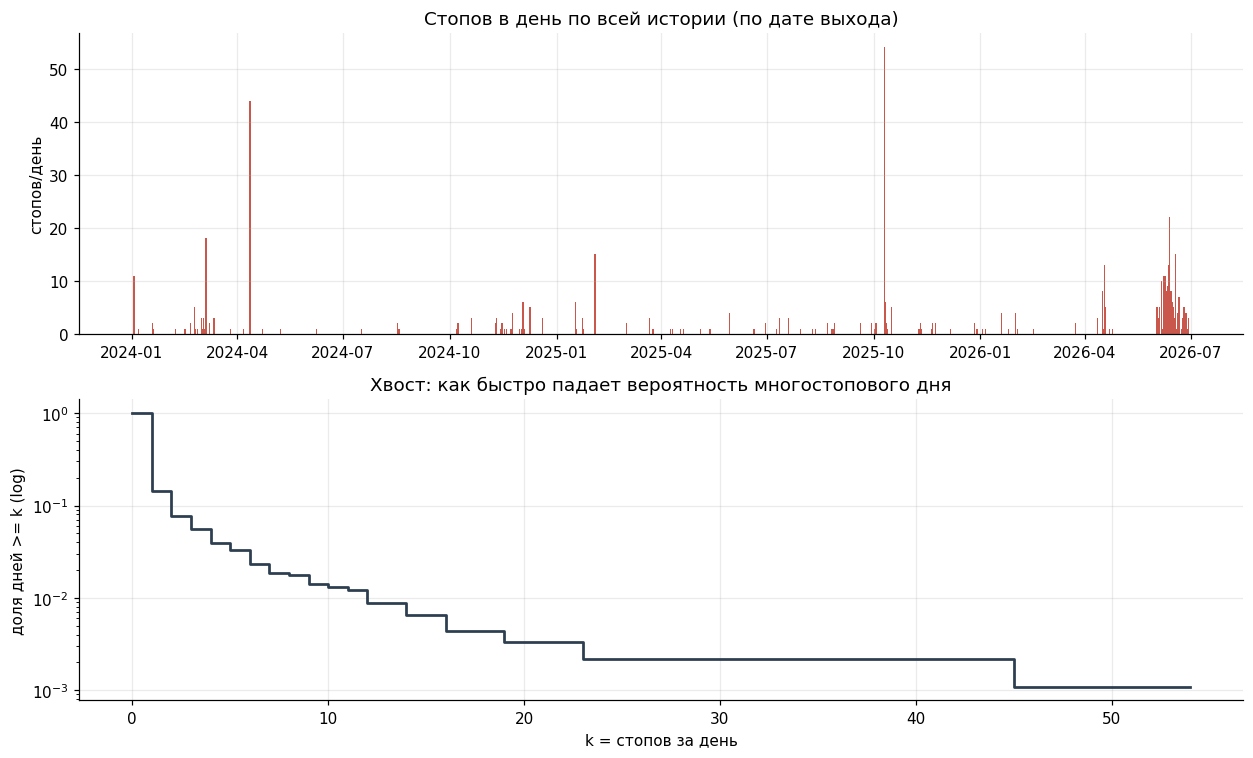

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1, figsize=(11.5,7))
ax[0].bar(spd.index, spd.values, width=1.0, color="#c0392b", alpha=0.85)
ax[0].set_title("Стопов в день по всей истории (по дате выхода)"); ax[0].set_ylabel("стопов/день")
# CCDF: доля дней с >= k стопами
ks = np.arange(0, int(spd.max())+1)
ccdf = [(spd>=k).mean() for k in ks]
ax[1].step(ks, ccdf, where="post", color="#2c3e50", lw=1.8)
ax[1].set_yscale("log"); ax[1].set_xlabel("k = стопов за день"); ax[1].set_ylabel("доля дней >= k (log)")
ax[1].set_title("Хвост: как быстро падает вероятность многостопового дня")
show("v2_nb01_stops_day")

### Явно: в какие ДНИ проходит бо́льшая часть стопов

Не проценты-перцентили, а конкретные даты — топ-дней по числу стопов и их накопленная доля.

In [4]:
top = spd[spd>0].sort_values(ascending=False)
tt = pd.DataFrame({"date": top.index.date, "stops": top.values})
tt["доля%"] = (tt["stops"]/total*100).round(1)
tt["накопл%"] = (tt["stops"].cumsum()/total*100).round(1)
print(f"ВСЕГО {total} стопов за {ndays} дней. Топ-дней по числу стопов:")
print(tt.head(20).to_string(index=False))
half = (tt["stops"].cumsum() >= total*0.5).idxmax()+1
print(f"\n-> ПОЛОВИНА всех стопов истории умещается в {half} худших дней "
      f"(из {ndays}, т.е. {half/ndays*100:.1f}% дней).")
print(f"-> В остальные {(spd==0).mean()*100:.0f}% дней стопов НЕТ вообще.")

ВСЕГО 515 стопов за 911 дней. Топ-дней по числу стопов:
      date  stops  доля%  накопл%
2025-10-10     54   10.5     10.5
2024-04-12     44    8.5     19.0
2026-06-13     22    4.3     23.3
2024-03-05     18    3.5     26.8
2025-02-03     15    2.9     29.7
2026-06-18     15    2.9     32.6
2026-04-18     13    2.5     35.1
2026-06-12     13    2.5     37.7
2026-06-08     11    2.1     39.8
2024-01-03     11    2.1     41.9
2026-06-09     11    2.1     44.1
2026-06-06     10    1.9     46.0
2026-06-11      9    1.7     47.8
2026-06-10      8    1.6     49.3
2026-06-14      8    1.6     50.9
2026-04-16      8    1.6     52.4
2026-06-21      7    1.4     53.8
2025-01-17      6    1.2     55.0
2026-06-15      6    1.2     56.1
2025-10-11      6    1.2     57.3

-> ПОЛОВИНА всех стопов истории умещается в 15 худших дней (из 911, т.е. 1.6% дней).
-> В остальные 86% дней стопов НЕТ вообще.


## B. LABUSDT за последние ~3 недели

Прогоняем детектор + scale-in вход + катастроф-стоп ТОЛЬКО по LABUSDT на окне 2026-06-20..07-14
(теми же правилами, что и вся стратегия) и смотрим, какие сделки словили стоп. Логика скопирована
1:1 из `_build_signals.py`.

In [5]:
# ── компактная 1:1-копия пайплайна из _build_signals.py, для одного символа ──
WIN=15; H=240; COOLDOWN=10; DAY=1440; FEE=0.00075; DELTA=0.02; VOL_MULT=3.0; SLIP=0.001
THR_P, THR_D = 0.05, 0.07

def clusters(c, thr, side):
    n=len(c)
    if n<WIN+5: return []
    r=np.full(n,np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=(r<=-thr) if side<0 else (r>=thr)
    out=[]; i=WIN
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        st=i; last=i; falses=0; j=i+1
        while j<n:
            if cond[j]: last=j; falses=0
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((st,last,cond)); i=last+COOLDOWN+1
    return out

def fills_time(c,st,last,cond,n): return [t for t in range(st,last+1) if cond[t] and t+1<n]
def fills_price(c,st,last,n):
    pos=[st]; lc=c[st]; t=st+1
    while t<=last:
        if c[t]<=lc*(1-DELTA): pos.append(t); lc=c[t]
        t+=1
    return [p for p in pos if p+1<n]

def exit_hold(c,h,l,avg,en,ex,side,cstop):
    for t in range(en+1, ex+1):
        if side>0:
            if h[t]/avg-1 >= cstop: return t, min(-cstop, -(c[t]/avg-1)) - SLIP, True
        else:
            if l[t]/avg-1 <= -cstop: return t, min(-cstop, (c[t]/avg-1)) - SLIP, True
    raw=c[ex]/avg-1
    return ex, (-raw if side>0 else raw), False

def one_symbol(sym, start, end):
    df=ohlcv(sym,start,end,"1min")
    c=df["close"].to_numpy("float64"); v=df["volume"].to_numpy("float64")
    h=df["high"].to_numpy("float64"); l=df["low"].to_numpy("float64"); ts=df.index; n=len(c)
    rows=[]
    for side,thr,cstop,gate in ((+1,THR_P,0.30,True),(-1,THR_D,0.20,False)):
        for (st,last,cond) in clusters(c,thr,side):
            ex=last+1+H
            if st<1 or st+1>=n or ex>=n: continue
            if gate:
                base=np.median(v[max(0,st-DAY):st]) if st>60 else np.nan
                surge=v[st-14:st+1].sum()/(base*15) if base and base>0 else np.nan
                if not (surge>=VOL_MULT): continue
                pos=fills_time(c,st,last,cond,n)
            else:
                pos=fills_price(c,st,last,n)
            if not pos: continue
            pr=np.array([c[p+1] for p in pos]); ws=np.arange(1,len(pr)+1,dtype=float); ws/=ws.sum()
            avg=(ws*pr).sum()
            exi,pnl_raw,stopped=exit_hold(c,h,l,avg,last,ex,side,cstop)
            rows.append(dict(stream=("pump" if side>0 else "dump"), entry=ts[st+1], exit=ts[exi],
                             avg=avg, pnl=pnl_raw-2*FEE, stopped=stopped, entry_i=st+1, exit_i=exi))
    return df, pd.DataFrame(rows).sort_values("entry").reset_index(drop=True)

lab_df, lab = one_symbol("LABUSDT","2026-06-20","2026-07-15")
print(f"LABUSDT 2026-06-20..07-14: {len(lab)} сделок, из них стопов {int(lab.stopped.sum())}")
lab_day = lab.assign(d=lab["exit"].dt.date).groupby("d").agg(
    trades=("pnl","size"), stops=("stopped","sum")).query("stops>0")
print("\nстопы LABUSDT по дням (только дни со стопами):")
print(lab_day.to_string())
print("-> видно, что стопы кучкуются в каскад 07-07/07-08 (LAB безостановочно падал, дамп-лонг")
print("   раз за разом ловил -20% на 'падающем ноже'), в остальные дни окна стопов почти нет.")
with pd.option_context("display.max_rows", 60, "display.width", 140):
    show_cols = lab[["stream","entry","exit","pnl","stopped"]].copy()
    show_cols["pnl"] = (show_cols["pnl"]*100).round(1)
    print(show_cols.to_string(index=False))

LABUSDT 2026-06-20..07-14: 156 сделок, из них стопов 31

стопы LABUSDT по дням (только дни со стопами):
            trades  stops
d                        
2026-07-03      10      1
2026-07-04      10      1
2026-07-07      19     10
2026-07-08      31     14
2026-07-09      13      1
2026-07-12       6      1
2026-07-13       9      3
-> видно, что стопы кучкуются в каскад 07-07/07-08 (LAB безостановочно падал, дамп-лонг
   раз за разом ловил -20% на 'падающем ноже'), в остальные дни окна стопов почти нет.
stream                     entry                      exit   pnl  stopped
  pump 2026-06-20 06:28:00+00:00 2026-06-20 10:28:00+00:00   2.9    False
  pump 2026-06-20 12:31:00+00:00 2026-06-20 16:31:00+00:00  -6.2    False
  pump 2026-06-20 16:10:00+00:00 2026-06-20 20:20:00+00:00   0.8    False
  pump 2026-06-21 03:05:00+00:00 2026-06-21 07:05:00+00:00  -9.8    False
  dump 2026-06-21 09:18:00+00:00 2026-06-21 13:18:00+00:00   1.9    False
  pump 2026-06-21 23:44:00+00:00 2026-06-22

[saved] notebooks\pump_dump_v2\_out\v2_nb01_lab.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb01_lab.png')

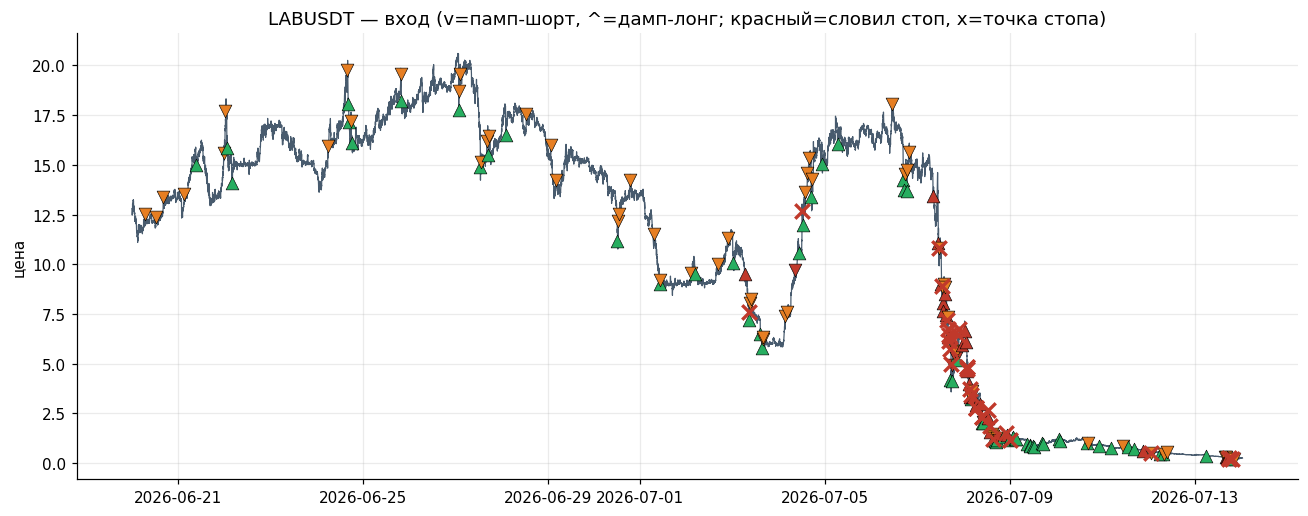

In [6]:
fig, ax = plt.subplots(figsize=(12,4.8))
px = lab_df["close"]
ax.plot(px.index, px.values, color="#34495e", lw=0.8, alpha=0.9)
for _,r in lab.iterrows():
    col = "#c0392b" if r.stopped else ("#e67e22" if r.stream=="pump" else "#27ae60")
    ax.scatter(r.entry, r.avg, marker=("v" if r.stream=="pump" else "^"), s=70,
               color=col, edgecolor="k", lw=0.4, zorder=5)
    if r.stopped:
        ax.scatter(r.exit, px.asof(r.exit), marker="x", s=90, color="#c0392b", lw=2.2, zorder=6)
ax.set_title("LABUSDT — вход (v=памп-шорт, ^=дамп-лонг; красный=словил стоп, x=точка стопа)")
ax.set_ylabel("цена")
show("v2_nb01_lab")

## Выводы

**Стопы РЕДКИ и СИЛЬНО сконцентрированы — не размазаны по времени.**

- Стоп-рейт низкий: **2.8%** всех событий (памп 1.8%, дамп 5.5% — дамп чаще: глубокий дамп чаще
  продолжает падать = «падающий нож»). В среднем 0.57 стоп/день.
- **Бо́льшая часть стопов проходит в считанные дни** (прямой ответ на вопрос): половина всех стопов
  истории умещается в ~несколько худших дней; худшие **1% дней держат ~40%** стопов, худшие 5% — **77%**,
  худшие 10% — **92%**. В **86% дней стопов нет вообще**. Gini ≈ **0.94**.
- Это НЕ случайность: индекс дисперсии var/mean ≫ 1, а многостоповые дни (≥10) при равномерной
  (Пуассон) модели были бы астрономически редки — в реальности они регулярны. Стопы приходят
  **пачками**: общерыночные риск-офф дни (например 2025-10-10 = пик стопов) и каскады отдельных монет.
- **LABUSDT — учебный пример каскада:** за 3 недели 31 стоп из 156 сделок, почти все в кластере
  **07-07 / 07-08**, когда LAB безостановочно падал и дамп-лонг раз за разом ловил −20% на падающем
  ноже. В тот же день памп-шорты по LAB, наоборот, дали +35…+56% — внутримонетная версия хеджа
  (падает цена → лонги-на-отскок стопятся, шорты выигрывают).

**Почему это ВАЖНО для риска (связь с оригиналом nb05/09):** просадка стратегии концентрируется в
редкие дни, а не копится равномерно. Хорошо — большинство времени спокойно; плохо — риск «пачечный»
(коррелированный): в один каскадный день можно словить пачку стопов сразу. Лимит 18 слотов и катастроф-стоп
именно для этого. Реальный несемплированный хвост (настоящая альт-мания) может дать день хуже всех
виденных в 2024–26.

**Следующие шаги (кандидаты):** (1) в те же топ-дни считать НЕ стопы-события, а реализованный урон
портфеля (через движок) — сколько стоит худший день в % NAV; (2) breadth-kill-switch: гасить вход, когда
за трейлинг-час стопов/дампов по рынку выше порога (причинный фильтр каскада); (3) запрет перезахода в
монету, которая только что словила стоп и всё ещё падает (LAB-каскад).